<a href="https://colab.research.google.com/github/teejx/CCDATSCL_PROJECT/blob/main/60_DAYS_PROJECT%20(but%20colorful%20version).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**IMPORTS**

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_ind, pearsonr
import statsmodels.api as sm

**CSV**

In [3]:
file_path = "60daysproject.csv"
data = pd.read_csv(file_path)
print(data.head())

   Day  Exercise  Stress  Sleep Workload
0    1         1       3    7.5   Medium
1    2         0       4    6.0    Heavy
2    3         1       2    8.0    Light
3    4         0       5    5.5    Heavy
4    5         1       3    7.0   Medium


**Data Cleaning**

In [4]:
# Convert Workload to numeric values
workload_map = {"Light": 1, "Medium": 2, "Heavy": 3}
data["Workload_Num"] = data["Workload"].map(workload_map)


# Check missing values
print(data.isnull().sum())

Day             0
Exercise        0
Stress          0
Sleep           0
Workload        0
Workload_Num    0
dtype: int64


**Graphs, Tables, and Summary statistic**

In [5]:
desc_stats = data[['Exercise','Sleep','Workload_Num','Stress']].agg(['mean','median','std']).T
print(desc_stats)
desc_stats.to_csv("descriptive_stats.csv")

                  mean  median       std
Exercise      0.566667     1.0  0.499717
Sleep         7.028333     7.0  0.951554
Workload_Num  1.900000     2.0  0.796177
Stress        3.216667     3.0  0.958312


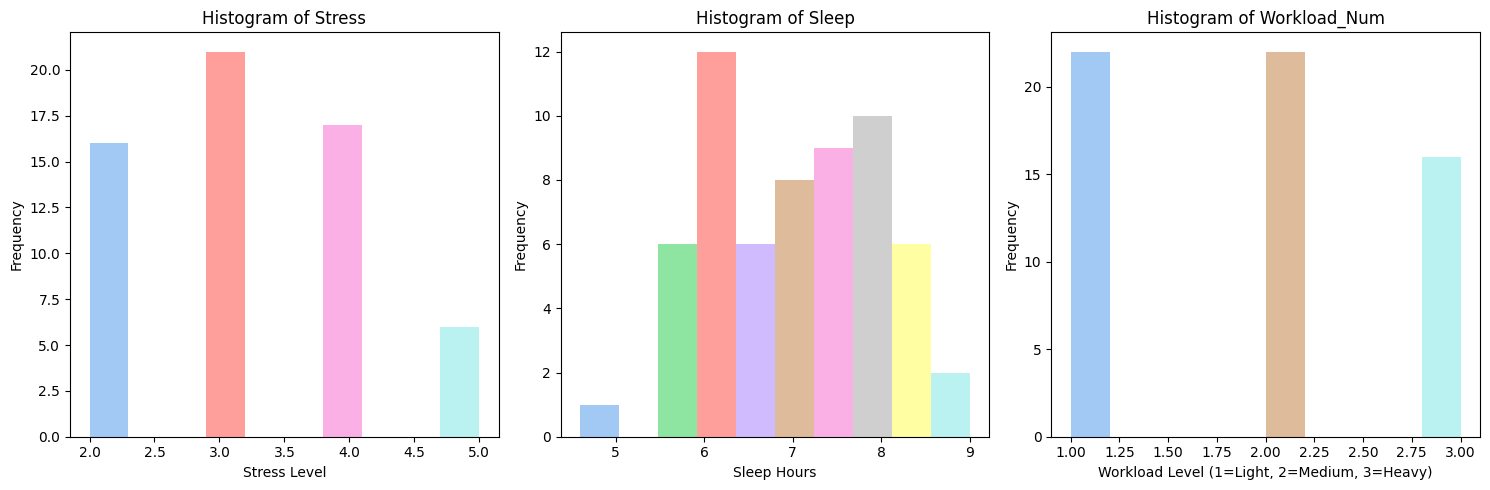

In [16]:
columns_for_hist = ['Stress','Sleep','Workload_Num']

# Create a figure and a set of subplots for each histogram
fig, axes = plt.subplots(nrows=1, ncols=len(columns_for_hist), figsize=(15, 5)) # Adjusted figsize for better layout

x_labels = {
    'Stress': 'Stress Level',
    'Sleep': 'Sleep Hours',
    'Workload_Num': 'Workload Level (1=Light, 2=Medium, 3=Heavy)'
}
y_label = 'Frequency'

for i, col_name in enumerate(columns_for_hist):
    ax = axes[i]

    n, bins, patches = ax.hist(data[col_name], bins=10)

    pastel_colors_bars = sns.color_palette("pastel", n_colors=len(patches))

    for j, patch in enumerate(patches):
        patch.set_facecolor(pastel_colors_bars[j])

    ax.set_xlabel(x_labels[col_name])
    ax.set_ylabel(y_label)
    ax.set_title(f'Histogram of {col_name}')

plt.tight_layout()
plt.savefig("histograms.png")
plt.show()

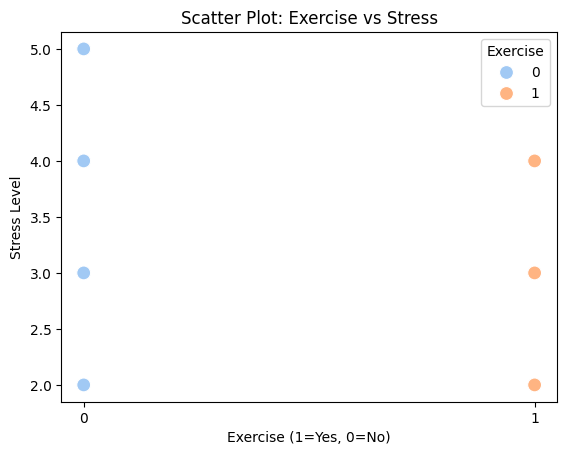

In [18]:
# Scatter Plot: Exercise vs Stress
plt.figure()
sns.scatterplot(x=data["Exercise"], y=data["Stress"], hue=data["Exercise"], palette="pastel", s=100)
plt.title("Scatter Plot: Exercise vs Stress")
plt.xlabel("Exercise (1=Yes, 0=No)")
plt.ylabel("Stress Level")
plt.xticks([0, 1])
plt.show()

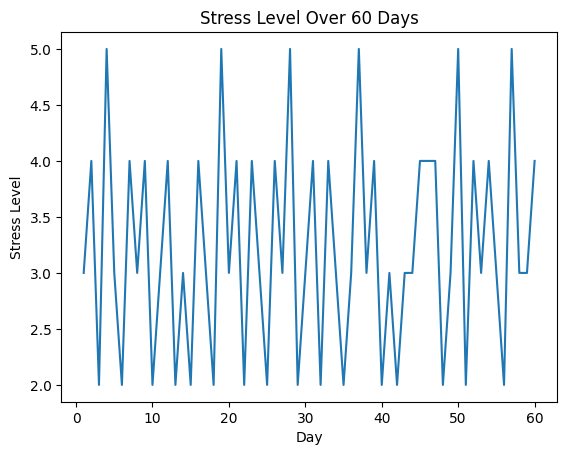

In [10]:
# Line Graph: Stress Over Time
plt.figure()
plt.plot(data["Day"], data["Stress"])
plt.title("Stress Level Over 60 Days")
plt.xlabel("Day")
plt.ylabel("Stress Level")
plt.show()

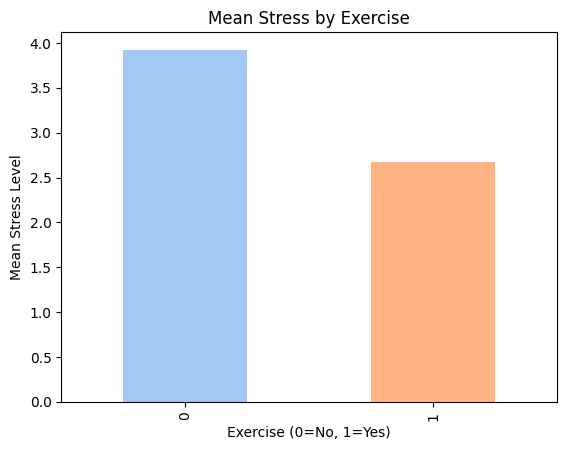

In [17]:
# Bar Graph: Mean Stress by Exercise
mean_stress = data.groupby("Exercise")["Stress"].mean()
plt.figure()

bars = mean_stress.plot(kind="bar")

pastel_colors_bars = sns.color_palette("pastel", n_colors=len(mean_stress))

for j, patch in enumerate(bars.patches):
    patch.set_facecolor(pastel_colors_bars[j])

plt.title("Mean Stress by Exercise")
plt.xlabel("Exercise (0=No, 1=Yes)")
plt.ylabel("Mean Stress Level")
plt.show()

**Correlation Analysis**

In [12]:
correlation_results = {
    'Variable 1': ['Exercise', 'Sleep', 'Workload'],
    'Variable 2': ['Stress', 'Stress', 'Stress'],
    'Pearson R': [
        pearsonr(data['Exercise'], data['Stress'])[0],
        pearsonr(data['Sleep'], data['Stress'])[0],
        pearsonr(data['Workload_Num'], data['Stress'])[0]
    ]
}

correlation_df = pd.DataFrame(correlation_results)
display(correlation_df)

,Variable 1,Variable 2,Pearson R
0,Exercise,Stress,-0.650050
1,Sleep,Stress,-0.544009
2,Workload,Stress,0.739734


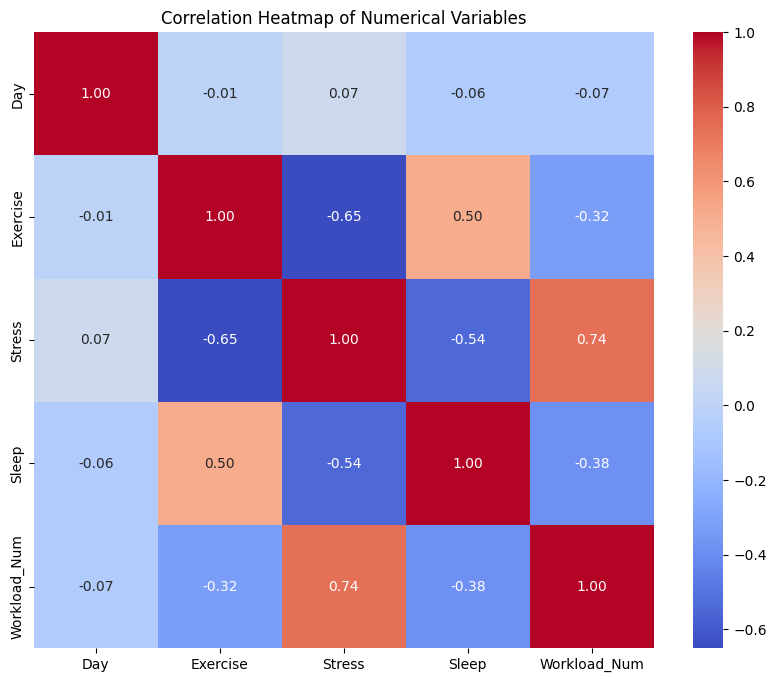

In [13]:
# Calculate the correlation matrix for numerical columns
correlation_matrix = data.select_dtypes(include=np.number).corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap of Numerical Variables')
plt.show()

**T - Test**

In [14]:
stress_exercise = data[data["Exercise"] == 1]["Stress"]
stress_no_exercise = data[data["Exercise"] == 0]["Stress"]

t_stat, p_value = ttest_ind(stress_exercise, stress_no_exercise)

t_test_results = pd.DataFrame({
    'Metric': ['T-statistic', 'P-value'],
    'Value': [t_stat, p_value]
})
display(t_test_results)

,Metric,Value
0,T-statistic,-6.514927e+00
1,P-value,1.903658e-08


**Regression Analysis**

In [15]:
X = data[["Exercise", "Sleep", "Workload_Num"]]
X = sm.add_constant(X)
y = data["Stress"]


model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                 Stress   R-squared:                       0.747
Model:                            OLS   Adj. R-squared:                  0.733
Method:                 Least Squares   F-statistic:                     54.99
Date:                Thu, 19 Feb 2026   Prob (F-statistic):           1.07e-16
Time:                        16:25:27   Log-Likelihood:                -40.896
No. Observations:                  60   AIC:                             89.79
Df Residuals:                      56   BIC:                             98.17
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const            3.2700      0.617      5.301   